[THÀNH CÔNG] Đã tìm thấy file: f:\Mô hình toán tài chính\Đồ án cuối kì\Dữ liệu Lịch sử VIC.csv
BƯỚC 1 — ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU VIC
Đọc thành công: f:\Mô hình toán tài chính\Đồ án cuối kì\Dữ liệu Lịch sử VIC.csv
Kích thước gốc: 249 hàng x 7 cột

5 dòng đầu:
         Ngày Lần cuối       Mở      Cao     Thấp     KL % Thay đổi
0  24/06/2026  230,500  229,000  242,000  227,100  3.75M      0.66%
1  23/06/2026  229,000  224,200  230,000  223,600  5.02M      4.19%
2  22/06/2026  219,800  205,500  219,800  203,100  3.51M      6.96%
3  19/06/2026  205,500  206,700  207,500  203,000  4.09M      0.05%
4  18/06/2026  205,400  196,000  205,400  195,100  6.43M      6.98%

Dữ liệu sau khi làm sạch:
        Date    Close     Open     High      Low     Volume  Pct_Change
0 2025-06-25  47900.0  48000.0  48300.0  47250.0  5310000.0        0.00
1 2025-06-26  47500.0  47500.0  48500.0  47500.0  3220000.0       -0.84
2 2025-06-27  47750.0  47500.0  48050.0  46200.0  6060000.0        0.53
3 2025-06-30  478

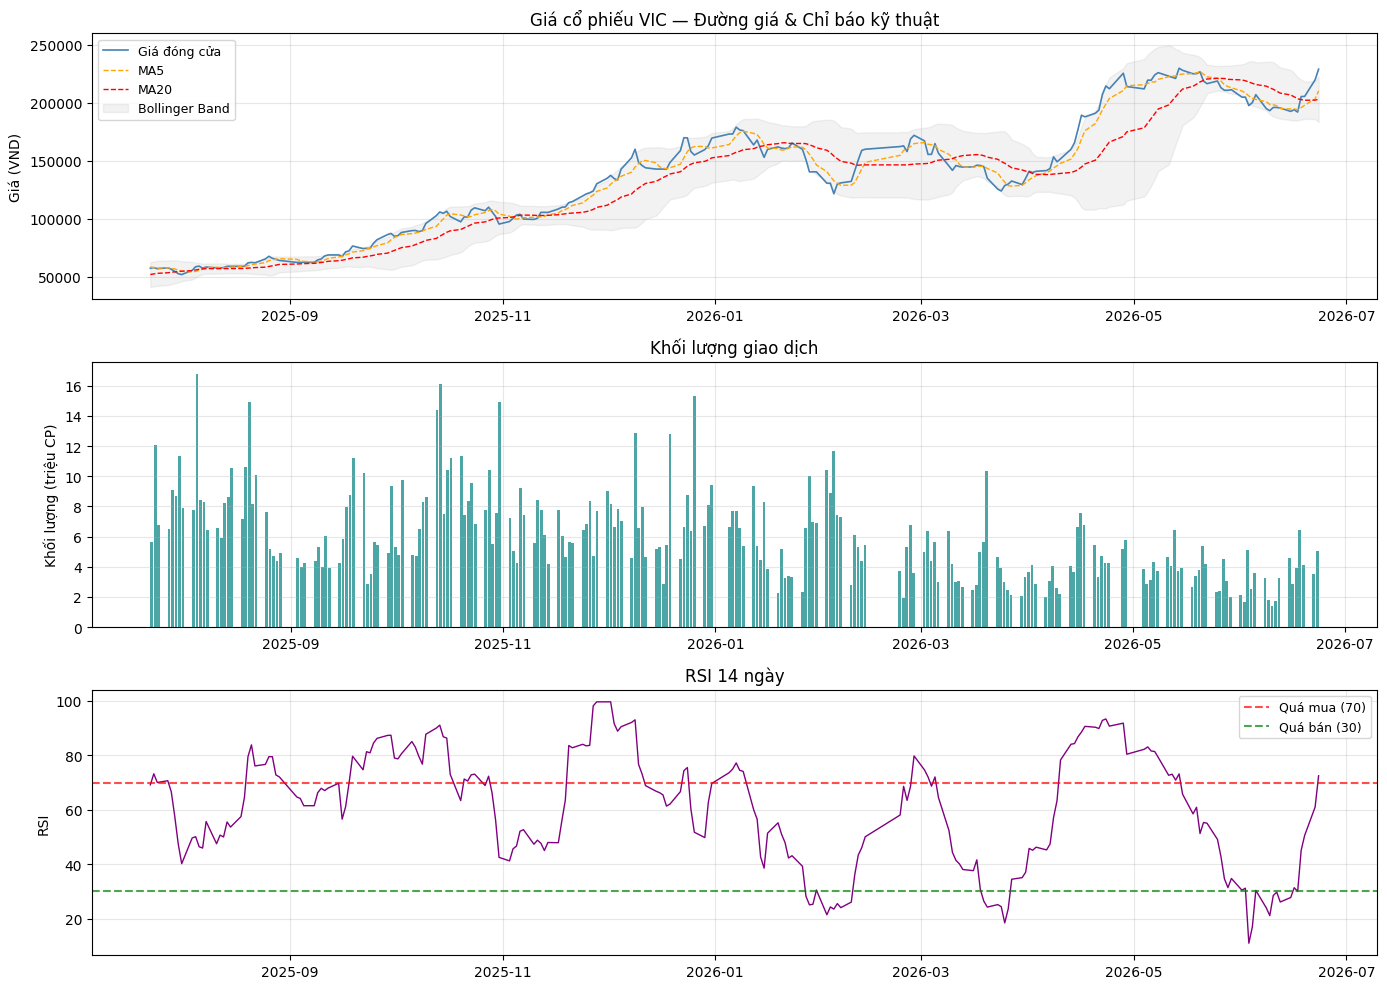

→ Đã lưu: f:\Mô hình toán tài chính\Đồ án cuối kì\VIC_Correlation.png


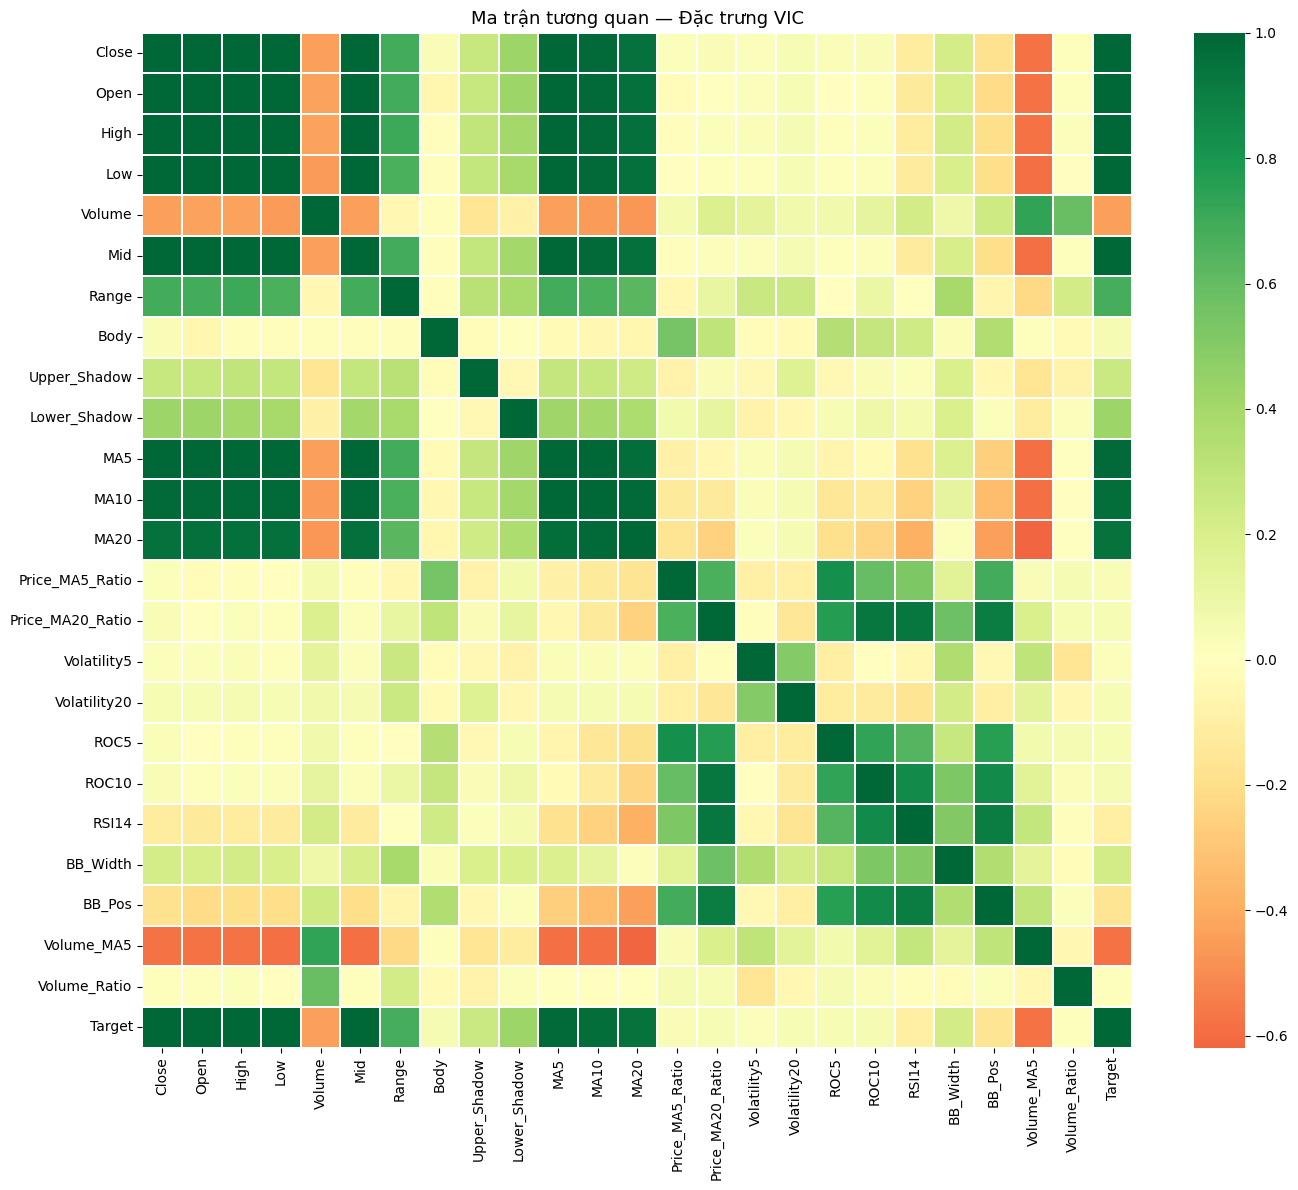

→ Đã lưu: f:\Mô hình toán tài chính\Đồ án cuối kì\VIC_Distributions.png


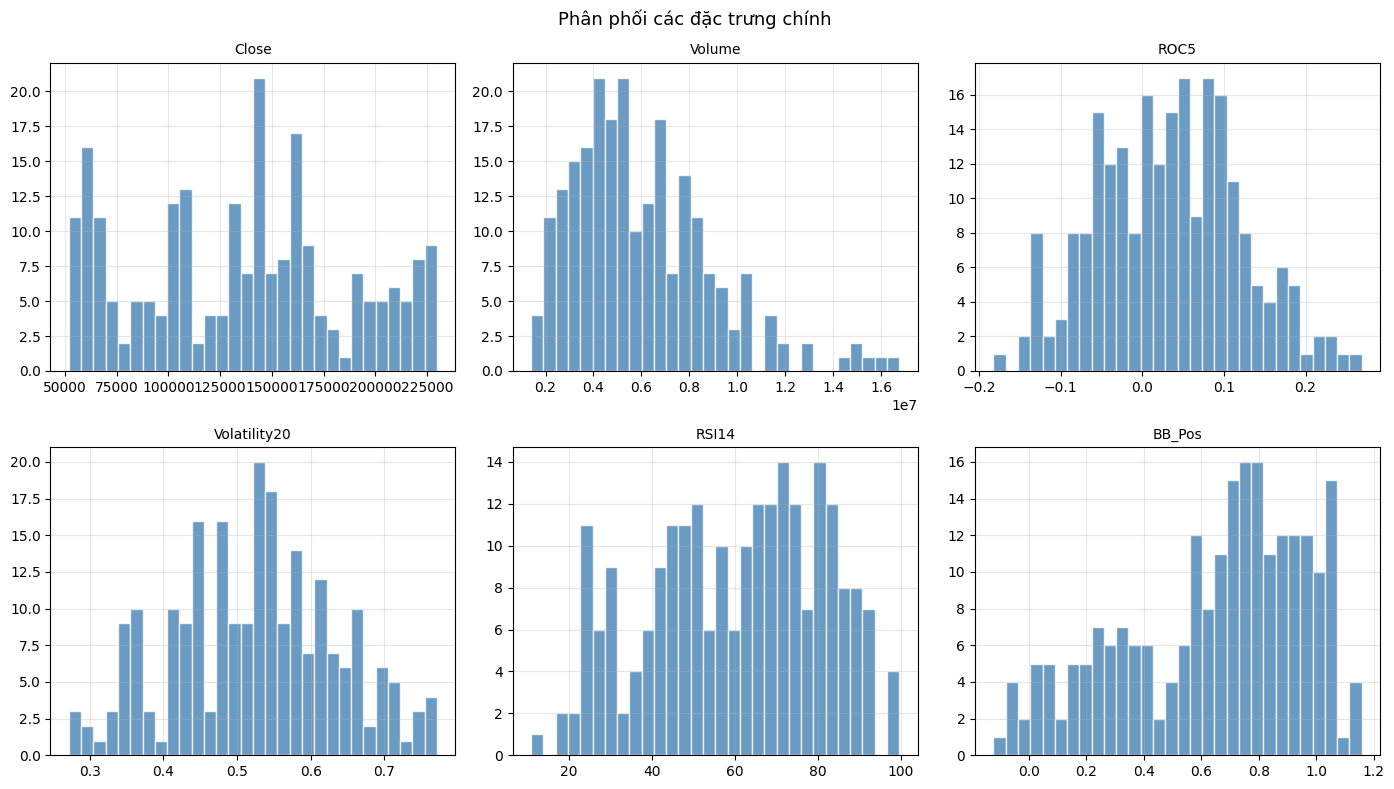


BƯỚC 4 — LỰA CHỌN ĐẶC TRƯNG

Xếp hạng đặc trưng theo F-statistic:
                      Score
Feature                    
Close             23775.491
Mid               15326.749
Low               14937.816
High              14235.915
Open              10430.310
MA5                8396.975
MA10               4198.876
MA20               1951.396
Range               192.029
Volume_MA5          112.650
Volume               53.143
Lower_Shadow         49.691
Upper_Shadow         16.184
BB_Width             11.081
BB_Pos                6.433
RSI14                 2.386
Body                  0.625
ROC10                 0.541
Price_MA20_Ratio      0.402
ROC5                  0.375
Volatility20          0.347
Price_MA5_Ratio       0.260
Volatility5           0.090
Volume_Ratio          0.012
→ Đã lưu: f:\Mô hình toán tài chính\Đồ án cuối kì\VIC_FeatureImportance.png


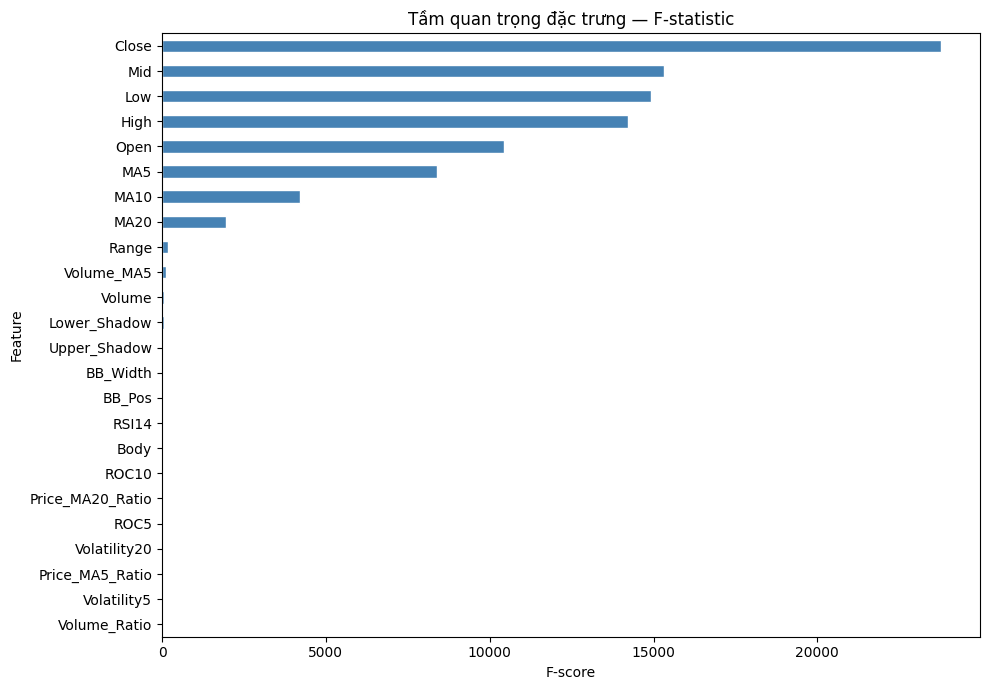


Top 10 đặc trưng được chọn:
  ['Close', 'Mid', 'Low', 'High', 'Open', 'MA5', 'MA10', 'MA20', 'Range', 'Volume_MA5']

BƯỚC 5 — PHÂN CHIA & CHUẨN HÓA DỮ LIỆU
Train : 182 mẫu  (80%)
Test  : 46  mẫu  (20%)
Chuẩn hóa StandardScaler đã áp dụng (fit trên train only)

BƯỚC 6 — HUẤN LUYỆN VÀ SO SÁNH 11 MÔ HÌNH

Mô hình       CV MSE TB       CV Std      Train MSE       Test MSE
------------------------------------------------------------------
LR          24162954.74  15206547.42    19572476.17    42315202.75
LASSO       24044910.76  15136400.04    19574268.94    42196810.34
EN          36425000.96  18024359.93    30664971.79    59859788.47
KNN        133633090.54  62845371.48    26423814.29  2224391626.09
CART       126740514.26  50404588.73           0.00  2019071956.52
SVR       2442378810.42 1715500319.11  1209693490.38  7710094015.50
MLP       9902303928.28 5865575699.34  9242498054.01 16605017383.24
ABR        112629890.90  97539801.56    16200202.42  1421596961.84
GBR         86087533.70

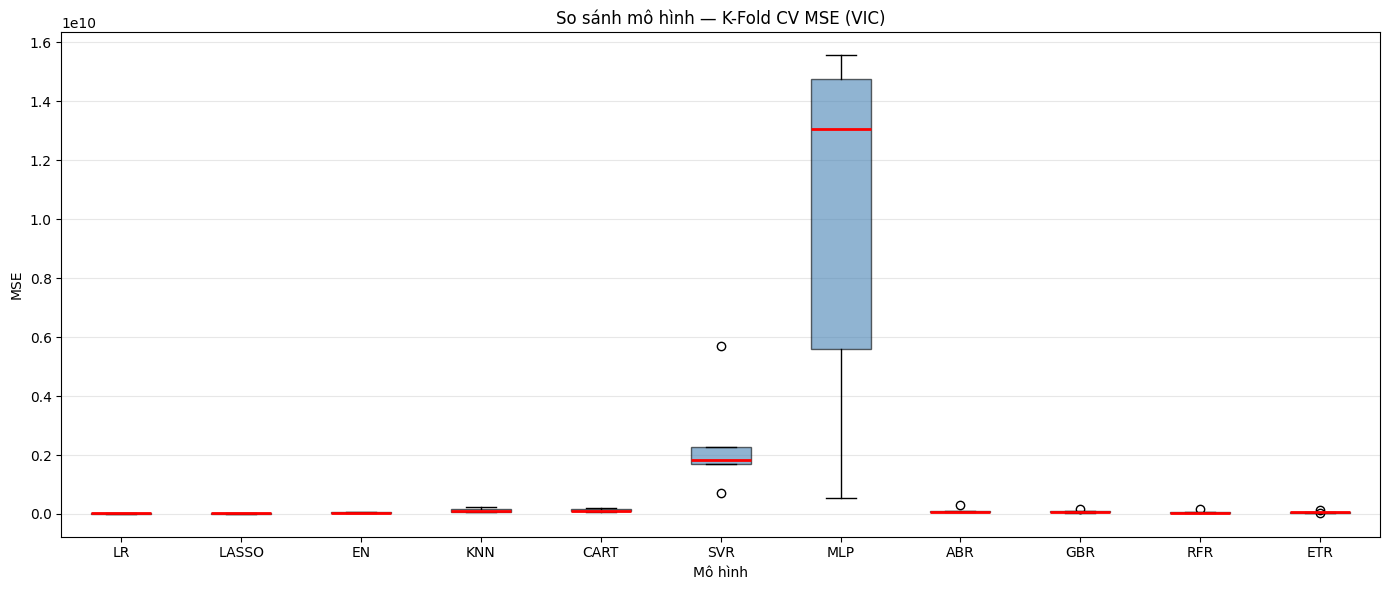

→ Đã lưu: f:\Mô hình toán tài chính\Đồ án cuối kì\VIC_TrainTest_Comparison.png


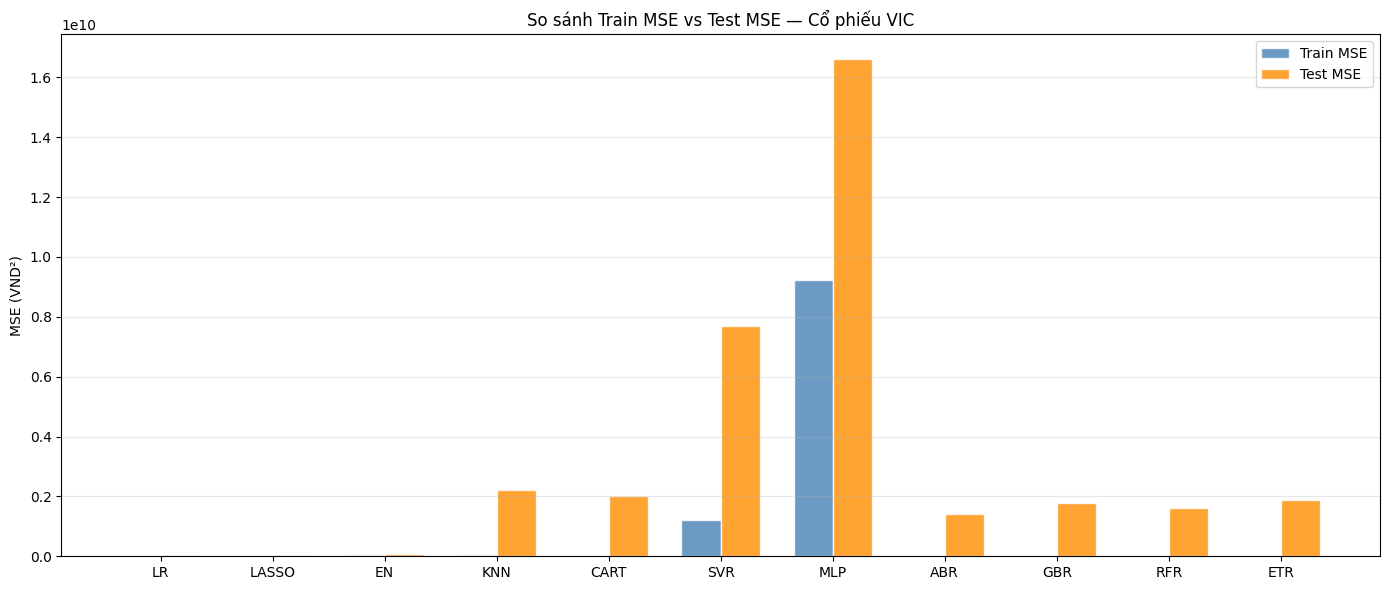


BƯỚC 8 — TINH CHỈNH MLP (GridSearchCV)
Cấu hình tốt nhất : {'activation': 'relu', 'hidden_layer_sizes': (64, 32, 16)}
CV MSE tốt nhất   : 5115070447.8008

Tất cả kết quả GridSearch:
                                                    params  mean_test_score  std_test_score
{'activation': 'relu', 'hidden_layer_sizes': (64, 32, 16)}       -5.115e+09       3.787e+09
   {'activation': 'relu', 'hidden_layer_sizes': (128, 64)}       -5.124e+09       2.261e+09
    {'activation': 'relu', 'hidden_layer_sizes': (64, 32)}       -9.902e+09       5.866e+09
      {'activation': 'relu', 'hidden_layer_sizes': (128,)}       -1.521e+10       7.807e+09
       {'activation': 'relu', 'hidden_layer_sizes': (64,)}       -1.530e+10       7.841e+09
       {'activation': 'relu', 'hidden_layer_sizes': (32,)}       -1.535e+10       7.862e+09
      {'activation': 'tanh', 'hidden_layer_sizes': (128,)}       -1.538e+10       7.868e+09
   {'activation': 'tanh', 'hidden_layer_sizes': (128, 64)}       -1.539e+10      

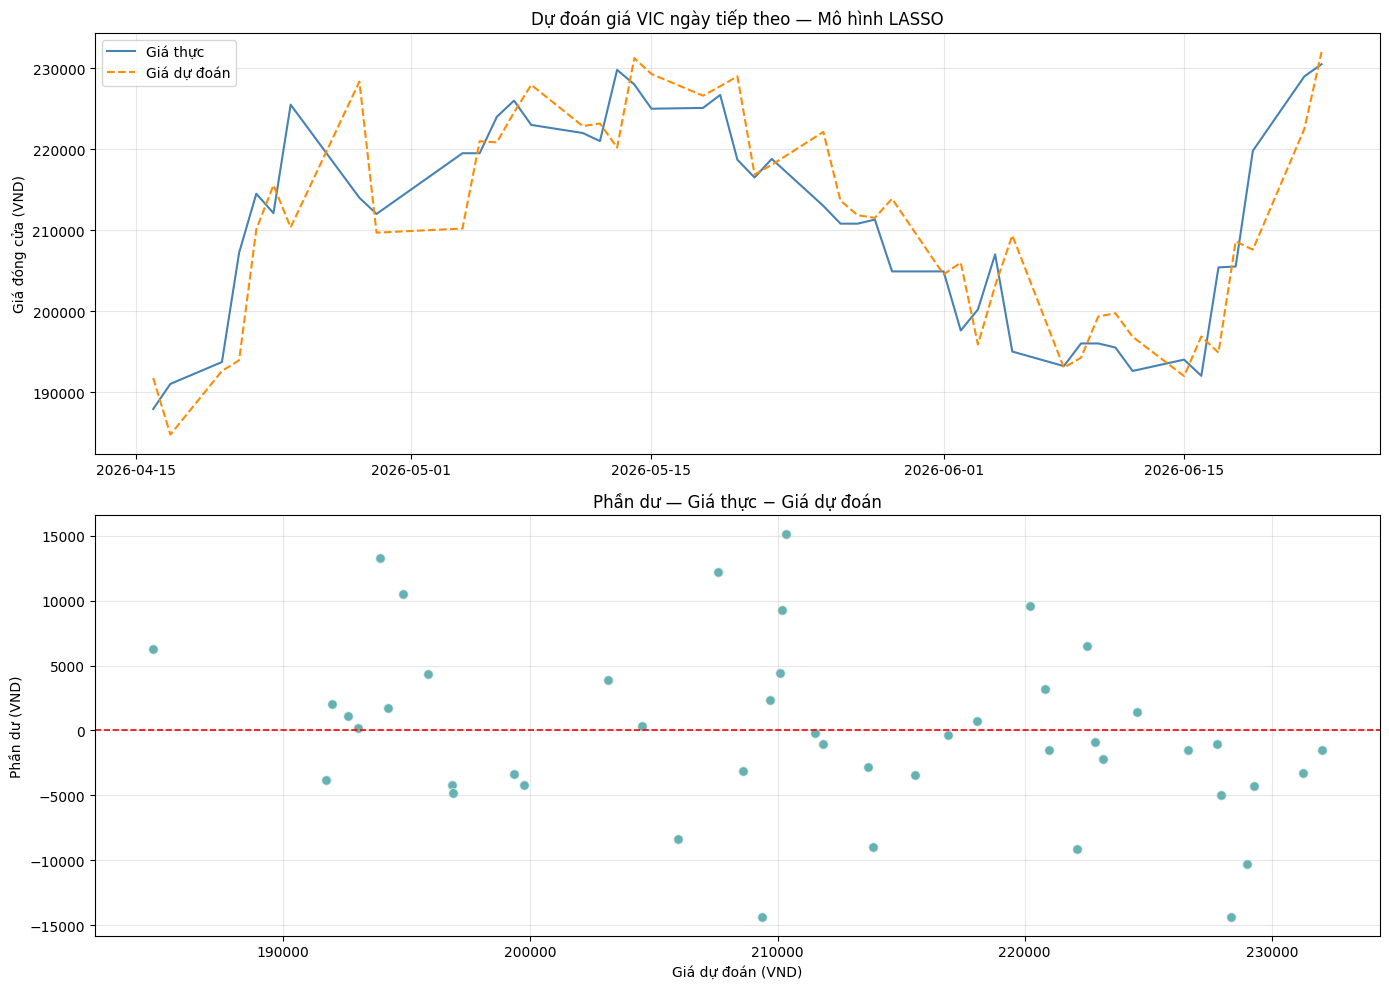


BƯỚC 10 — THỰC NGHIỆM: CHỈ DÙNG CHỈ BÁO KỸ THUẬT
(Không có Close / Open / High / Low / Mid tuyệt đối)

Mô hình          Test MSE      Test RMSE
------------------------------------------
LR          3951775664.98       62863.15
KNN         6410833491.30       80067.68
CART        8315269619.57       91188.10
SVR         7521691732.73       86727.69
MLP        30612901542.99      174965.43
GBR         5791739929.90       76103.48
RFR         6530454929.80       80811.23
ETR         5955290204.26       77170.53
→ Đã lưu: f:\Mô hình toán tài chính\Đồ án cuối kì\VIC_Experiment2.png


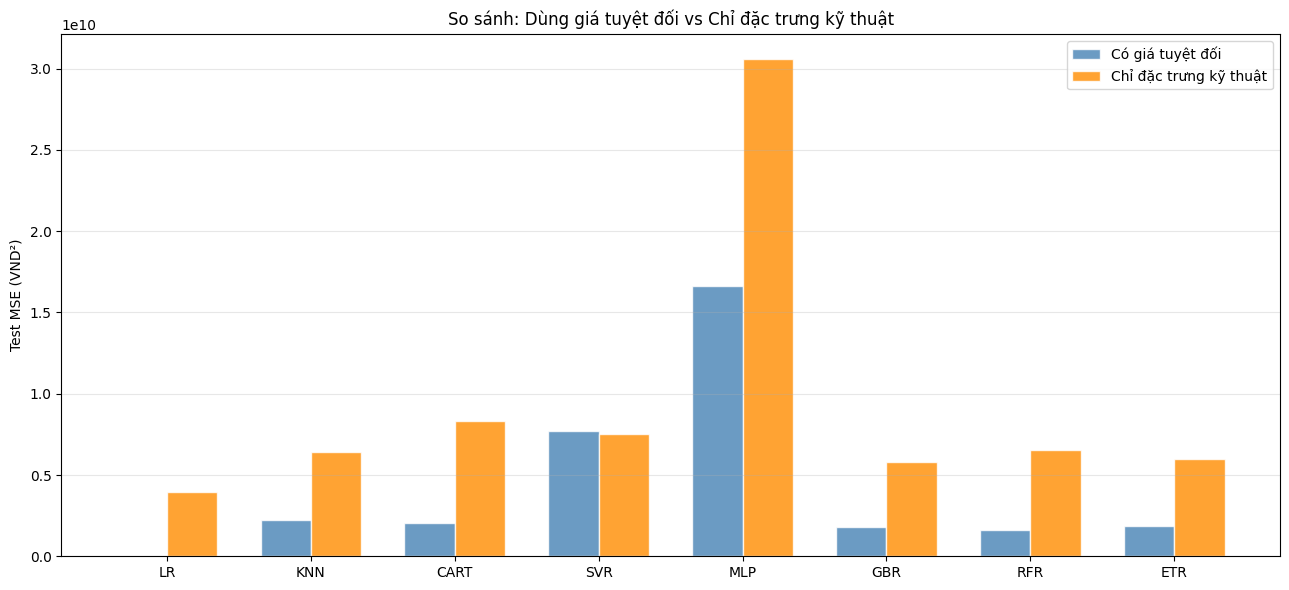


TỔNG KẾT KẾT QUẢ

Bảng xếp hạng mô hình (Test MSE tăng dần):
Mô hình  CV MSE TB    CV Std  Train MSE  Test MSE  Test RMSE
  LASSO  2.404e+07 1.514e+07  1.957e+07 4.220e+07   6495.907
     LR  2.416e+07 1.521e+07  1.957e+07 4.232e+07   6505.014
     EN  3.643e+07 1.802e+07  3.066e+07 5.986e+07   7736.911
    ABR  1.126e+08 9.754e+07  1.620e+07 1.422e+09  37704.071
    RFR  7.284e+07 4.614e+07  3.962e+06 1.615e+09  40185.404
    GBR  8.609e+07 4.235e+07  3.323e+05 1.792e+09  42337.374
    ETR  6.302e+07 4.104e+07  0.000e+00 1.878e+09  43332.853
   CART  1.267e+08 5.040e+07  0.000e+00 2.019e+09  44934.085
    KNN  1.336e+08 6.285e+07  2.642e+07 2.224e+09  47163.456
    SVR  2.442e+09 1.716e+09  1.210e+09 7.710e+09  87807.141
    MLP  9.902e+09 5.866e+09  9.242e+09 1.661e+10 128860.457

  Mô hình tốt nhất : LASSO
  Test MSE         : 42,196,810.34
  Test RMSE        : 6,495.91 VND
  Sai lệch TB      : ≈ 6,496 VND / phiên

Tất cả biểu đồ đã lưu tại: f:\Mô hình toán tài chính\Đồ án cuối kì


In [1]:
# ==============================================================
#  PIPELINE DỰ ĐOÁN GIÁ CỔ PHIẾU VIC — PHIÊN BẢN VS CODE
# ==============================================================
#
#  CÀI ĐẶT THƯ VIỆN (chạy 1 lần trong terminal):
#  pip install numpy pandas matplotlib seaborn scikit-learn
#
#  CÁCH DÙNG:
#  1. Đặt file "Dữ_liệu_Lịch_sử_VIC.csv" cùng thư mục với file .py này
#  2. Mở terminal trong VS Code → python VIC_ML_Pipeline_VSCode.py
#  3. Các biểu đồ PNG sẽ được lưu cùng thư mục
# ==============================================================

import os
import sys
import numpy as np
import pandas as pd
from matplotlib import pyplot
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, AdaBoostRegressor
)
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression

# ==============================================================
# CẤU HÌNH — chỉnh sửa đường dẫn nếu cần
# ==============================================================
# Mặc định: tìm file CSV cùng thư mục với script này
BASE_DIR = os.getcwd() 

# ĐƯỜNG DẪN FILE: Bạn chọn 1 trong 2 cách dưới đây
# Cách 1: Dùng đường dẫn tuyệt đối (an toàn nhất)
CSV_FILE = r"f:\Mô hình toán tài chính\Đồ án cuối kì\Dữ liệu Lịch sử VIC.csv"

# Cách 2: Nếu file ở cùng thư mục với notebook/script (bỏ comment để dùng)
# CSV_FILE = os.path.join(BASE_DIR, "Dữ liệu Lịch sử VIC.csv")

OUTPUT_DIR = BASE_DIR

# ==============================================================
# KIỂM TRA FILE ĐẦU VÀO
# ==============================================================
if not os.path.exists(CSV_FILE):
    print(f"[LỖI] Không tìm thấy file tại: {CSV_FILE}")
    print("Vui lòng kiểm tra lại đường dẫn ổ đĩa F của bạn.")
    sys.exit(1)
else:
    print(f"[THÀNH CÔNG] Đã tìm thấy file: {CSV_FILE}")

def save_fig(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    pyplot.savefig(path, dpi=120, bbox_inches='tight')
    print(f"→ Đã lưu: {path}")

# ==============================================================
# BƯỚC 1 — ĐỌC VÀ LÀM SẠCH DỮ LIỆU
# ==============================================================
print("=" * 60)
print("BƯỚC 1 — ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU VIC")
print("=" * 60)

df_raw = pd.read_csv(CSV_FILE)
print(f"Đọc thành công: {CSV_FILE}")
print(f"Kích thước gốc: {df_raw.shape[0]} hàng x {df_raw.shape[1]} cột")
print("\n5 dòng đầu:")
print(df_raw.head())

# --- Hàm parse số dạng "230,500" hoặc "0.66%" ---
def parse_number(s):
    if isinstance(s, str):
        s = s.replace(',', '').replace('%', '').strip()
        try:
            return float(s)
        except ValueError:
            return np.nan
    return float(s)

# --- Hàm parse khối lượng "3.75M" / "500K" ---
def parse_volume(s):
    if isinstance(s, str):
        s = s.strip()
        if s.upper().endswith('M'):
            return float(s[:-1]) * 1_000_000
        elif s.upper().endswith('K'):
            return float(s[:-1]) * 1_000
        else:
            return parse_number(s)
    return float(s)

df = pd.DataFrame()
df['Date']       = pd.to_datetime(df_raw['Ngày'], dayfirst=True)
df['Close']      = df_raw['Lần cuối'].apply(parse_number)
df['Open']       = df_raw['Mở'].apply(parse_number)
df['High']       = df_raw['Cao'].apply(parse_number)
df['Low']        = df_raw['Thấp'].apply(parse_number)
df['Volume']     = df_raw['KL'].apply(parse_volume)
df['Pct_Change'] = df_raw['% Thay đổi'].apply(parse_number)

# Sắp xếp theo thời gian tăng dần (dữ liệu gốc từ mới → cũ)
df = df.sort_values('Date').reset_index(drop=True)

print("\nDữ liệu sau khi làm sạch:")
print(df.head())
print(f"\nKhoảng thời gian: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Số phiên giao dịch: {len(df)}")

# ==============================================================
# BƯỚC 2 — XÂY DỰNG ĐẶC TRƯNG KỸ THUẬT (Feature Engineering)
# ==============================================================
print("\n" + "=" * 60)
print("BƯỚC 2 — XÂY DỰNG ĐẶC TRƯNG KỸ THUẬT")
print("=" * 60)

# -- Nến Nhật --
df['Mid']          = (df['High'] + df['Low']) / 2
df['Range']        = df['High'] - df['Low']
df['Body']         = df['Close'] - df['Open']
df['Upper_Shadow'] = df['High'] - df[['Close', 'Open']].max(axis=1)
df['Lower_Shadow'] = df[['Close', 'Open']].min(axis=1) - df['Low']

# -- Đường trung bình động --
df['MA5']  = df['Close'].rolling(window=5).mean()
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()

# -- Tỷ lệ giá / MA --
df['Price_MA5_Ratio']  = df['Close'] / df['MA5']
df['Price_MA20_Ratio'] = df['Close'] / df['MA20']

# -- Biến động lịch sử (annualized) --
df['Log_Return']  = np.log(df['Close'] / df['Close'].shift(1))
df['Volatility5'] = df['Log_Return'].rolling(window=5).std()  * np.sqrt(252)
df['Volatility20']= df['Log_Return'].rolling(window=20).std() * np.sqrt(252)

# -- Momentum --
df['ROC5']  = df['Close'].pct_change(periods=5)
df['ROC10'] = df['Close'].pct_change(periods=10)

# -- RSI 14 ngày --
delta = df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI14'] = 100 - (100 / (1 + gain / (loss + 1e-9)))

# -- Bollinger Bands --
std20            = df['Close'].rolling(20).std()
df['BB_Upper']   = df['MA20'] + 2 * std20
df['BB_Lower']   = df['MA20'] - 2 * std20
df['BB_Width']   = (df['BB_Upper'] - df['BB_Lower']) / (df['MA20'] + 1e-9)
df['BB_Pos']     = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'] + 1e-9)

# -- Khối lượng --
df['Volume_MA5']   = df['Volume'].rolling(5).mean()
df['Volume_Ratio'] = df['Volume'] / (df['Volume_MA5'] + 1e-9)

# -- Biến mục tiêu: giá đóng cửa NGÀY MAI --
df['Target'] = df['Close'].shift(-1)

# Xoá hàng NaN phát sinh từ rolling & shift
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

feature_cols = [
    'Close', 'Open', 'High', 'Low', 'Volume',
    'Mid', 'Range', 'Body', 'Upper_Shadow', 'Lower_Shadow',
    'MA5', 'MA10', 'MA20',
    'Price_MA5_Ratio', 'Price_MA20_Ratio',
    'Volatility5', 'Volatility20',
    'ROC5', 'ROC10', 'RSI14',
    'BB_Width', 'BB_Pos',
    'Volume_MA5', 'Volume_Ratio',
]

print(f"Số mẫu sau feature engineering: {len(df)}")
print(f"Số đặc trưng: {len(feature_cols)}")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")

# ==============================================================
# BƯỚC 3 — PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)
# ==============================================================
print("\n" + "=" * 60)
print("BƯỚC 3 — PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)")
print("=" * 60)

dataset = df[feature_cols + ['Target']].copy()
pd.set_option('display.precision', 3)
print("\nThống kê mô tả:")
print(dataset.describe())

# --- Biểu đồ 1: Giá, Khối lượng, RSI ---
fig, axes = pyplot.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df['Date'], df['Close'],    color='steelblue', linewidth=1.2, label='Giá đóng cửa')
axes[0].plot(df['Date'], df['MA5'],      color='orange',    linewidth=1,   label='MA5',  linestyle='--')
axes[0].plot(df['Date'], df['MA20'],     color='red',       linewidth=1,   label='MA20', linestyle='--')
axes[0].fill_between(df['Date'], df['BB_Lower'], df['BB_Upper'],
                     alpha=0.1, color='gray', label='Bollinger Band')
axes[0].set_title('Giá cổ phiếu VIC — Đường giá & Chỉ báo kỹ thuật')
axes[0].set_ylabel('Giá (VND)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].bar(df['Date'], df['Volume'] / 1e6, color='teal', alpha=0.7)
axes[1].set_title('Khối lượng giao dịch')
axes[1].set_ylabel('Khối lượng (triệu CP)')
axes[1].grid(alpha=0.3)

axes[2].plot(df['Date'], df['RSI14'], color='purple', linewidth=1)
axes[2].axhline(70, color='red',   linestyle='--', alpha=0.7, label='Quá mua (70)')
axes[2].axhline(30, color='green', linestyle='--', alpha=0.7, label='Quá bán (30)')
axes[2].set_title('RSI 14 ngày')
axes[2].set_ylabel('RSI')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

pyplot.tight_layout()
save_fig('VIC_EDA_Price.png')
pyplot.show()

# --- Biểu đồ 2: Ma trận tương quan ---
fig, ax = pyplot.subplots(figsize=(14, 12))
corr = dataset.corr()
sns.heatmap(corr, annot=False, cmap='RdYlGn', center=0,
            linewidths=0.3, ax=ax,
            xticklabels=corr.columns, yticklabels=corr.columns)
ax.set_title('Ma trận tương quan — Đặc trưng VIC', fontsize=13)
pyplot.tight_layout()
save_fig('VIC_Correlation.png')
pyplot.show()

# --- Biểu đồ 3: Phân phối 6 đặc trưng chính ---
key_feats = ['Close', 'Volume', 'ROC5', 'Volatility20', 'RSI14', 'BB_Pos']
fig, axes = pyplot.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), key_feats):
    ax.hist(dataset[col].dropna(), bins=30, color='steelblue',
            edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.grid(alpha=0.3)
pyplot.suptitle('Phân phối các đặc trưng chính', fontsize=13)
pyplot.tight_layout()
save_fig('VIC_Distributions.png')
pyplot.show()

# ==============================================================
# BƯỚC 4 — LỰA CHỌN ĐẶC TRƯNG (SelectKBest / F-statistic)
# ==============================================================
print("\n" + "=" * 60)
print("BƯỚC 4 — LỰA CHỌN ĐẶC TRƯNG")
print("=" * 60)

X_all = dataset[feature_cols].values
Y     = dataset['Target'].values

selector     = SelectKBest(k='all', score_func=f_regression)
selector.fit(X_all, Y)
feat_scores  = pd.DataFrame({'Feature': feature_cols,
                              'Score':  selector.scores_}).set_index('Feature')
feat_scores  = feat_scores.sort_values('Score', ascending=False)
print("\nXếp hạng đặc trưng theo F-statistic:")
print(feat_scores.to_string())

fig, ax = pyplot.subplots(figsize=(10, 7))
feat_scores['Score'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Tầm quan trọng đặc trưng — F-statistic', fontsize=12)
ax.set_xlabel('F-score')
ax.invert_yaxis()
pyplot.tight_layout()
save_fig('VIC_FeatureImportance.png')
pyplot.show()

top10 = feat_scores.head(10).index.tolist()
print(f"\nTop 10 đặc trưng được chọn:\n  {top10}")
X = dataset[top10].values

# ==============================================================
# BƯỚC 5 — PHÂN CHIA & CHUẨN HÓA DỮ LIỆU
# ==============================================================
print("\n" + "=" * 60)
print("BƯỚC 5 — PHÂN CHIA & CHUẨN HÓA DỮ LIỆU")
print("=" * 60)

# Dữ liệu chuỗi thời gian → KHÔNG shuffle, chia theo thứ tự
validation_size = 0.2
train_size      = int(len(X) * (1 - validation_size))

X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit trên train, transform trên test
X_test  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} mẫu  ({(1-validation_size)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]}  mẫu  ({validation_size*100:.0f}%)")
print("Chuẩn hóa StandardScaler đã áp dụng (fit trên train only)")

# ==============================================================
# BƯỚC 6 — HUẤN LUYỆN VÀ SO SÁNH 11 MÔ HÌNH
# ==============================================================
print("\n" + "=" * 60)
print("BƯỚC 6 — HUẤN LUYỆN VÀ SO SÁNH 11 MÔ HÌNH")
print("=" * 60)

models = [
    ('LR',    LinearRegression()),
    ('LASSO', Lasso(alpha=0.1)),
    ('EN',    ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ('KNN',   KNeighborsRegressor(n_neighbors=5)),
    ('CART',  DecisionTreeRegressor(random_state=7)),
    ('SVR',   SVR(kernel='rbf', C=100, gamma='scale')),
    ('MLP',   MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=7)),
    ('ABR',   AdaBoostRegressor(random_state=7)),
    ('GBR',   GradientBoostingRegressor(n_estimators=200, random_state=7)),
    ('RFR',   RandomForestRegressor(n_estimators=200, random_state=7)),
    ('ETR',   ExtraTreesRegressor(n_estimators=200, random_state=7)),
]

num_folds = 5        # nhỏ hơn 10 vì dataset chỉ ~182 mẫu train
scoring   = 'neg_mean_squared_error'

names, kfold_results, train_results, test_results = [], [], [], []

print(f"\n{'Mô hình':<8} {'CV MSE TB':>14} {'CV Std':>12} "
      f"{'Train MSE':>14} {'Test MSE':>14}")
print("-" * 66)

for name, model in models:
    names.append(name)

    # K-Fold cross validation (shuffle=False giữ thứ tự thời gian)
    kfold      = KFold(n_splits=num_folds, shuffle=False)
    cv_results = -1 * cross_val_score(model, X_train, Y_train,
                                      cv=kfold, scoring=scoring)
    kfold_results.append(cv_results)

    # Huấn luyện toàn bộ tập train
    model.fit(X_train, Y_train)
    train_mse = mean_squared_error(Y_train, model.predict(X_train))
    test_mse  = mean_squared_error(Y_test,  model.predict(X_test))
    train_results.append(train_mse)
    test_results.append(test_mse)

    print(f"{name:<8} {cv_results.mean():>14.2f} {cv_results.std():>12.2f} "
          f"{train_mse:>14.2f} {test_mse:>14.2f}")

# ==============================================================
# BƯỚC 7 — TRỰC QUAN HÓA KẾT QUẢ SO SÁNH
# ==============================================================
print("\n" + "=" * 60)
print("BƯỚC 7 — TRỰC QUAN HÓA KẾT QUẢ SO SÁNH")
print("=" * 60)

# --- Boxplot K-Fold ---
fig, ax = pyplot.subplots(figsize=(14, 6))
ax.boxplot(kfold_results, labels=names, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('So sánh mô hình — K-Fold CV MSE (VIC)', fontsize=12)
ax.set_ylabel('MSE')
ax.set_xlabel('Mô hình')
ax.grid(axis='y', alpha=0.3)
pyplot.tight_layout()
save_fig('VIC_KFold_Comparison.png')
pyplot.show()

# --- Train vs Test MSE ---
fig, ax = pyplot.subplots(figsize=(14, 6))
ind   = np.arange(len(names))
width = 0.35
ax.bar(ind - width/2, train_results, width, label='Train MSE',
       color='steelblue', alpha=0.8, edgecolor='white')
ax.bar(ind + width/2, test_results,  width, label='Test MSE',
       color='darkorange', alpha=0.8, edgecolor='white')
ax.set_title('So sánh Train MSE vs Test MSE — Cổ phiếu VIC', fontsize=12)
ax.set_ylabel('MSE (VND²)')
ax.set_xticks(ind)
ax.set_xticklabels(names)
ax.legend()
ax.grid(axis='y', alpha=0.3)
pyplot.tight_layout()
save_fig('VIC_TrainTest_Comparison.png')
pyplot.show()

# ==============================================================
# BƯỚC 8 — TINH CHỈNH SIÊU THAM SỐ MLP (GridSearchCV)
# ==============================================================
print("\n" + "=" * 60)
print("BƯỚC 8 — TINH CHỈNH MLP (GridSearchCV)")
print("=" * 60)

param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (128,),
                           (64, 32), (128, 64), (64, 32, 16)],
    'activation': ['relu', 'tanh'],
}
grid = GridSearchCV(
    estimator=MLPRegressor(max_iter=1000, random_state=7),
    param_grid=param_grid,
    scoring=scoring,
    cv=KFold(n_splits=5, shuffle=False),
    n_jobs=-1,
    verbose=0,
)
grid_result = grid.fit(X_train, Y_train)

print(f"Cấu hình tốt nhất : {grid_result.best_params_}")
print(f"CV MSE tốt nhất   : {-grid_result.best_score_:.4f}")

cv_df = pd.DataFrame(grid_result.cv_results_)
print("\nTất cả kết quả GridSearch:")
print(cv_df[['params', 'mean_test_score', 'std_test_score']]
      .sort_values('mean_test_score', ascending=False)
      .to_string(index=False))

# ==============================================================
# BƯỚC 9 — ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT TRÊN TẬP TEST
# ==============================================================
print("\n" + "=" * 60)
print("BƯỚC 9 — ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT")
print("=" * 60)

best_idx   = int(np.argmin(test_results))
best_name  = names[best_idx]
best_model = dict(models)[best_name]
best_model.fit(X_train, Y_train)

Y_pred_test  = best_model.predict(X_test)
Y_pred_train = best_model.predict(X_train)

mse_test  = mean_squared_error(Y_test, Y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test  = np.mean(np.abs(Y_test - Y_pred_test))
mape_test = np.mean(np.abs((Y_test - Y_pred_test) / (Y_test + 1e-9))) * 100

print(f"\nMô hình tốt nhất: {best_name}")
print(f"\n{'Chỉ số':<25} {'Giá trị':>15}")
print("-" * 42)
print(f"{'MSE  (Test)':<25} {mse_test:>15.2f}")
print(f"{'RMSE (Test)':<25} {rmse_test:>15.2f} VND")
print(f"{'MAE  (Test)':<25} {mae_test:>15.2f} VND")
print(f"{'MAPE (Test)':<25} {mape_test:>14.2f} %")

# --- Biểu đồ dự đoán & residuals ---
# Căn ngày cho tập test (bù offset từ rolling windows)
offset     = len(df) - len(Y)          # số hàng bị loại bởi dropna
dates_full = df['Date'].values
dates_test = dates_full[offset + train_size: offset + train_size + len(Y_test)]

fig, axes = pyplot.subplots(2, 1, figsize=(14, 10))

if len(dates_test) == len(Y_test):
    axes[0].plot(dates_test, Y_test,      label='Giá thực',    color='steelblue',  linewidth=1.5)
    axes[0].plot(dates_test, Y_pred_test, label='Giá dự đoán', color='darkorange', linewidth=1.5, linestyle='--')
else:
    axes[0].plot(Y_test,      label='Giá thực',    color='steelblue',  linewidth=1.5)
    axes[0].plot(Y_pred_test, label='Giá dự đoán', color='darkorange', linewidth=1.5, linestyle='--')

axes[0].set_title(f'Dự đoán giá VIC ngày tiếp theo — Mô hình {best_name}', fontsize=12)
axes[0].set_ylabel('Giá đóng cửa (VND)')
axes[0].legend()
axes[0].grid(alpha=0.3)

residuals = Y_test - Y_pred_test
axes[1].scatter(Y_pred_test, residuals, alpha=0.6, color='teal',
                edgecolors='white', s=50)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_title('Phần dư — Giá thực − Giá dự đoán', fontsize=12)
axes[1].set_xlabel('Giá dự đoán (VND)')
axes[1].set_ylabel('Phần dư (VND)')
axes[1].grid(alpha=0.3)

pyplot.tight_layout()
save_fig('VIC_Predictions.png')
pyplot.show()

# ==============================================================
# BƯỚC 10 — THỰC NGHIỆM: DỰ ĐOÁN KHÔNG DÙNG GIÁ TUYỆT ĐỐI
# (Tương tự loại bỏ Sigma trong bài toán quyền chọn)
# ==============================================================
print("\n" + "=" * 60)
print("BƯỚC 10 — THỰC NGHIỆM: CHỈ DÙNG CHỈ BÁO KỸ THUẬT")
print("(Không có Close / Open / High / Low / Mid tuyệt đối)")
print("=" * 60)

indirect_features = [
    'Volume', 'Range', 'Body', 'Upper_Shadow', 'Lower_Shadow',
    'Price_MA5_Ratio', 'Price_MA20_Ratio',
    'Volatility5', 'Volatility20',
    'ROC5', 'ROC10', 'RSI14',
    'BB_Width', 'BB_Pos', 'Volume_Ratio',
]

X2       = dataset[indirect_features].values
X2_train = X2[:train_size]
X2_test  = X2[train_size:]

scaler2  = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test  = scaler2.transform(X2_test)

models2 = [
    ('LR',   LinearRegression()),
    ('KNN',  KNeighborsRegressor(n_neighbors=5)),
    ('CART', DecisionTreeRegressor(random_state=7)),
    ('SVR',  SVR(kernel='rbf', C=100, gamma='scale')),
    ('MLP',  MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=7)),
    ('GBR',  GradientBoostingRegressor(n_estimators=200, random_state=7)),
    ('RFR',  RandomForestRegressor(n_estimators=200, random_state=7)),
    ('ETR',  ExtraTreesRegressor(n_estimators=200, random_state=7)),
]

names2, test_results2 = [], []
print(f"\n{'Mô hình':<8} {'Test MSE':>16} {'Test RMSE':>14}")
print("-" * 42)

for name, model in models2:
    names2.append(name)
    model.fit(X2_train, Y_train)
    pred  = model.predict(X2_test)
    t_mse = mean_squared_error(Y_test, pred)
    test_results2.append(t_mse)
    print(f"{name:<8} {t_mse:>16.2f} {np.sqrt(t_mse):>14.2f}")

# --- So sánh hai thực nghiệm ---
common = [n for n in names2 if n in names]
r1     = [test_results[names.index(n)]   for n in common]
r2     = [test_results2[names2.index(n)] for n in common]

fig, ax = pyplot.subplots(figsize=(13, 6))
ind2  = np.arange(len(common))
width = 0.35
ax.bar(ind2 - width/2, r1, width, label='Có giá tuyệt đối',
       color='steelblue', alpha=0.8, edgecolor='white')
ax.bar(ind2 + width/2, r2, width, label='Chỉ đặc trưng kỹ thuật',
       color='darkorange', alpha=0.8, edgecolor='white')
ax.set_title('So sánh: Dùng giá tuyệt đối vs Chỉ đặc trưng kỹ thuật', fontsize=12)
ax.set_ylabel('Test MSE (VND²)')
ax.set_xticks(ind2)
ax.set_xticklabels(common)
ax.legend()
ax.grid(axis='y', alpha=0.3)
pyplot.tight_layout()
save_fig('VIC_Experiment2.png')
pyplot.show()

# ==============================================================
# TỔNG KẾT
# ==============================================================
print("\n" + "=" * 60)
print("TỔNG KẾT KẾT QUẢ")
print("=" * 60)

results_df = pd.DataFrame({
    'Mô hình':   names,
    'CV MSE TB': [r.mean() for r in kfold_results],
    'CV Std':    [r.std()  for r in kfold_results],
    'Train MSE': train_results,
    'Test MSE':  test_results,
    'Test RMSE': [np.sqrt(r) for r in test_results],
}).sort_values('Test MSE')

print("\nBảng xếp hạng mô hình (Test MSE tăng dần):")
print(results_df.to_string(index=False))

best = results_df.iloc[0]
print(f"\n{'='*60}")
print(f"  Mô hình tốt nhất : {best['Mô hình']}")
print(f"  Test MSE         : {best['Test MSE']:,.2f}")
print(f"  Test RMSE        : {best['Test RMSE']:,.2f} VND")
print(f"  Sai lệch TB      : ≈ {best['Test RMSE']:,.0f} VND / phiên")
print(f"{'='*60}")

print(f"\nTất cả biểu đồ đã lưu tại: {OUTPUT_DIR}")
print("Hoàn thành!")